Forest fire detection using data from NASA satellites (VIIRS,MODIS)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

In [ ]:
df = pd.read_csv('FileName.csv')
df.shape

(7689, 14)

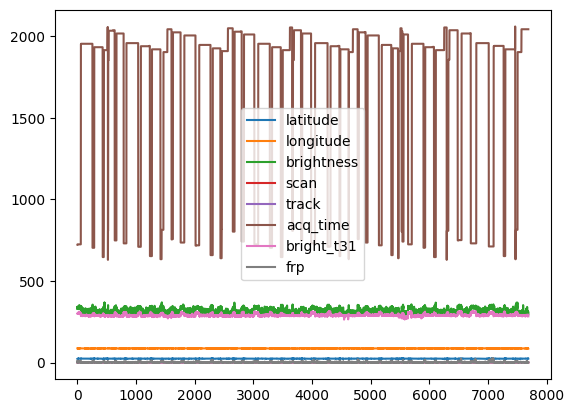

In [ ]:
df.plot()
plt.show()

In [ ]:
df.info()

In [ ]:
df.describe()

,latitude,longitude,brightness,scan,track,acq_time,bright_t31,frp
count,7689.000000,7689.000000,7689.000000,7689.000000,7689.000000,7689.000000,7689.000000,7689.000000
mean,23.575314,86.295941,311.636978,0.448001,0.472779,1717.817792,290.107506,2.141643
std,0.446396,0.711826,14.741495,0.083730,0.113505,501.460407,7.236486,1.837483
min,22.223050,83.629160,295.010000,0.320000,0.360000,629.000000,262.850000,0.160000
25%,23.564610,86.071500,299.990000,0.390000,0.370000,1914.000000,285.610000,1.070000
50%,23.692910,86.384210,305.690000,0.420000,0.430000,1946.000000,288.110000,1.620000
75%,23.770630,86.726370,322.970000,0.500000,0.550000,2004.000000,291.940000,2.540000
max,25.047440,88.151370,367.000000,0.790000,0.780000,2059.000000,315.450000,26.170000


In [ ]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,22.33617,86.88833,330.11,0.38,0.36,2026-01-01,722,N20,VIIRS,n,2.0NRT,301.44,1.55,D
1,23.14597,87.23266,341.33,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,302.03,12.12,D
2,23.08469,86.93766,337.53,0.38,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,297.79,2.42,D
3,23.13065,87.26598,328.56,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,298.28,1.45,D
4,23.12513,87.25162,341.90,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,299.78,3.54,D


In [ ]:
# Check Unique values of target variable
df.confidence.value_counts()

,count
confidence,
n,7363
l,317
h,9


 ## Confidence Column Meanings
l (Low Confidence):  These are daytime pixels often associated with ***sun glint*** or lower relative temperature anomalies (<15 K) in the infrared channel. They have a higher risk of being false positives.

n (Nominal Confidence): These are pixels free from sun glint during the day and marked by a strong temperature anomaly (>15 K) during both day and night. These are generally considered ***reliable fire detections***.

h (High Confidence): These are associated with pixels that are saturated during day or night. These indicate very intense heat and are the ***most certain fire detections***

In [ ]:
# checking for null values
df.isnull().sum()

,0
latitude,0
longitude,0
brightness,0
scan,0
track,0
acq_date,0
acq_time,0
satellite,0
instrument,0
confidence,0


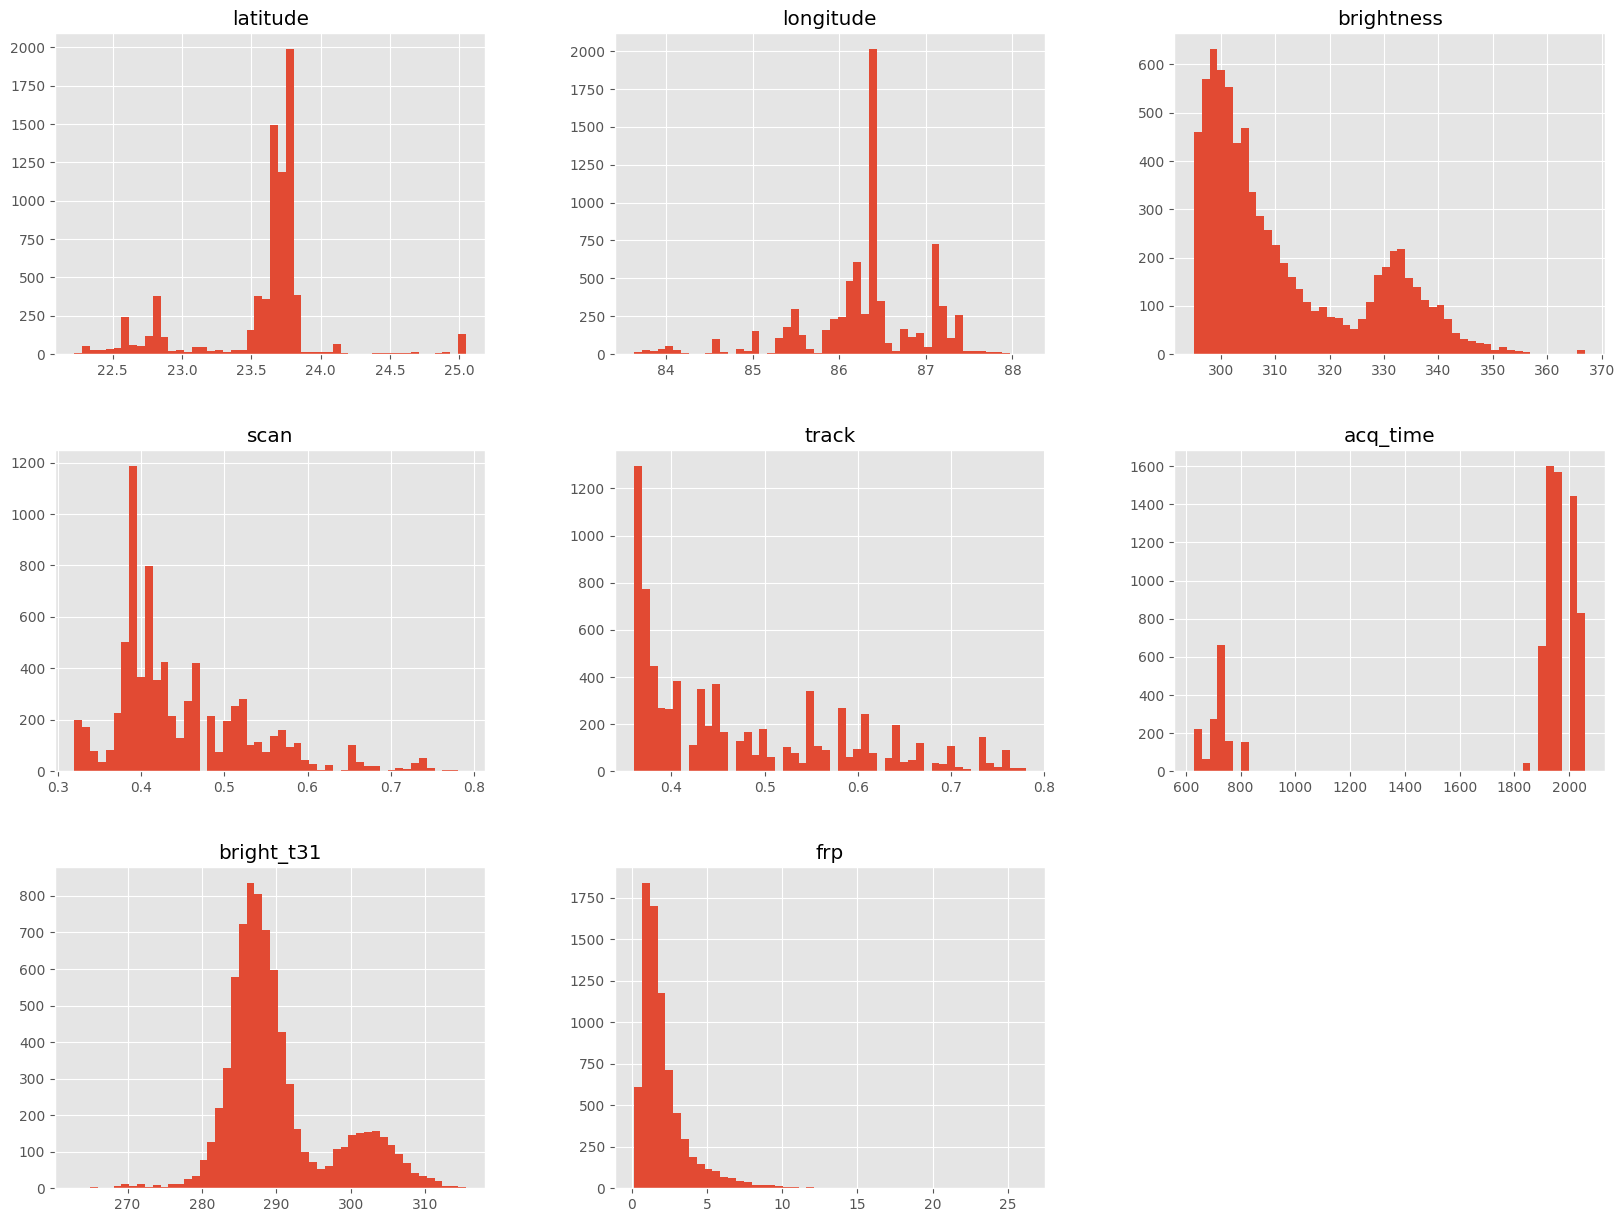

In [ ]:
# PLot density plot for all features
plt.style.use('ggplot')
df.hist(bins=50, figsize=(20,15), ec = 'b')
plt.show()

In [ ]:
# Percentage for PieChart
percentage = df.confidence.value_counts(normalize=True)*100
percentage

,proportion
confidence,
n,95.760177
l,4.122773
h,0.117050


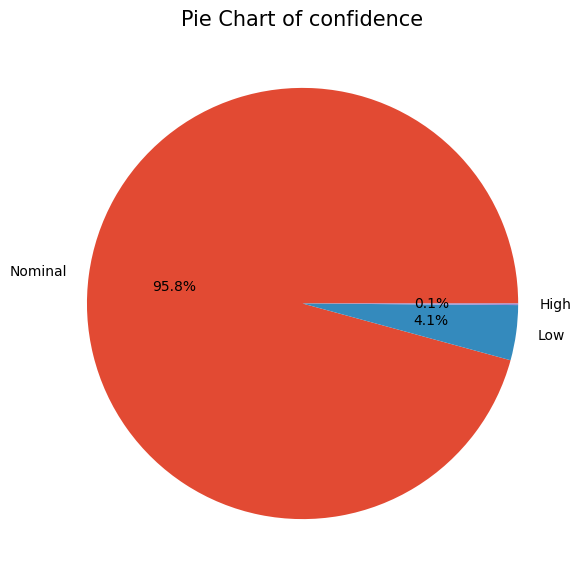

In [ ]:
#plotting PieChart
confidencelabels = ["Nominal", "Low", "High"]
plt.figure(figsize =(12, 7))
plt.pie(percentage,labels = confidencelabels,autopct='%1.1f%%')
plt.title ("Pie Chart of confidence", fontsize = 15)
plt.show()

## Excessive data skewness/Imbalance.

We need to balance the dataset for proper functionality of model.

In [ ]:
import pandas as pd

# 1. Filter out 'l' (Low Confidence) entirely
# This removes potential false alarms from sun glint or mining reflections
df_cleaned = df[df['confidence'] != 'l'].copy()

# 2. Combine 'n' and 'h' into a single "Confirmed Fire" class
# We can represent this as 1 (Fire) for the model
df_cleaned['confidence_binary'] = df_cleaned['confidence'].replace({'n': 1, 'h': 1})

# Optional: Verify the new distribution
print("New Class Distribution:")
print(df_cleaned['confidence_binary'].value_counts(normalize=True))

# 3. Check the first few rows to ensure it worked
print(df_cleaned[['confidence', 'confidence_binary']].head())


New Class Distribution:
confidence_binary
1    1.0
Name: proportion, dtype: float64
  confidence  confidence_binary
0          n                  1
1          n                  1
2          n                  1
3          n                  1
4          n                  1


/tmp/ipykernel_2960/1003020843.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['confidence_binary'] = df_cleaned['confidence'].replace({'n': 1, 'h': 1})


Building a binary classifier (Fire vs. No-Fire) requires both positive and negative examples. Since FIRMS only provides "Fire" detections, current dataset has a Selection Bias—the model will only see fires and won't know what a "normal" forest looks like.
To fix this for Jharkhand model, we need to generate Synthetic Non-Fire points (also called Pseudo-Absence points)

In [ ]:
# 1. Define Jharkhand bounds
lat_min, lat_max = 22.0, 25.0
lon_min, lon_max = 83.5, 88.0

# 2. Determine how many non-fire points you need
# (Matching the number of fire points creates a balanced 50/50 dataset)
num_samples = len(df_cleaned)

# 3. Generate random coordinates
non_fire_lats = np.random.uniform(lat_min, lat_max, num_samples)
non_fire_lons = np.random.uniform(lon_min, lon_max, num_samples)

# 4. Create the Non-Fire Dataframe
df_non_fire = pd.DataFrame({
    'latitude': non_fire_lats,
    'longitude': non_fire_lons,
    'confidence_binary': 0, # 0 = No Fire
    'frp': 0,               # No heat power
    'brightness': 300       # Average ambient temperature (Kelvin)
})

# 5. Merge with your cleaned Fire data
df_final = pd.concat([df_cleaned, df_non_fire], ignore_index=True)

print(f"Total dataset size: {len(df_final)}")
print(df_final['confidence_binary'].value_counts())

Total dataset size: 14744
confidence_binary
1    7372
0    7372
Name: count, dtype: int64


In [ ]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,22.33617,86.88833,330.11,0.38,0.36,2026-01-01,722,N20,VIIRS,n,2.0NRT,301.44,1.55,D
1,23.14597,87.23266,341.33,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,302.03,12.12,D
2,23.08469,86.93766,337.53,0.38,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,297.79,2.42,D
3,23.13065,87.26598,328.56,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,298.28,1.45,D
4,23.12513,87.25162,341.90,0.39,0.36,2026-01-01,724,N20,VIIRS,n,2.0NRT,299.78,3.54,D


In [ ]:
df_final.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_binary
0,22.33617,86.88833,330.11,0.38,0.36,2026-01-01,722.0,N20,VIIRS,n,2.0NRT,301.44,1.55,D,1
1,23.14597,87.23266,341.33,0.39,0.36,2026-01-01,724.0,N20,VIIRS,n,2.0NRT,302.03,12.12,D,1
2,23.08469,86.93766,337.53,0.38,0.36,2026-01-01,724.0,N20,VIIRS,n,2.0NRT,297.79,2.42,D,1
3,23.13065,87.26598,328.56,0.39,0.36,2026-01-01,724.0,N20,VIIRS,n,2.0NRT,298.28,1.45,D,1
4,23.12513,87.25162,341.90,0.39,0.36,2026-01-01,724.0,N20,VIIRS,n,2.0NRT,299.78,3.54,D,1


In [ ]:
df_final.tail()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_binary
14739,23.171799,86.983266,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0
14740,22.867519,86.534436,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0
14741,22.472908,84.667764,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0
14742,24.606597,84.832935,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0
14743,23.587323,85.638563,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0


In [ ]:


# 1. Setup - Define the Jharkhand region and sample size
num_samples = len(df_cleaned)
lat_min, lat_max = 22.0, 25.0
lon_min, lon_max = 83.5, 88.0

# 2. Generate Base Data (Numeric and Categorical constants)
df_non_fire = pd.DataFrame({
    'latitude': np.random.uniform(lat_min, lat_max, num_samples),
    'longitude': np.random.uniform(lon_min, lon_max, num_samples),
    'confidence_binary': 0,
    'frp': 0.0,
    'brightness': 300.0,
    'bright_t31': 290.0,
    'scan': 1.0,
    'track': 1.0,
    'version': '6.1N',
    'satellite': 'Aqua',
    'instrument': 'MODIS'
})

# 3. FIX: Convert to datetime first, then generate random dates
# Ensure the column is in datetime format
df_cleaned['acq_date'] = pd.to_datetime(df_cleaned['acq_date'])

# Now .timestamp() will work because the computer knows these are dates
start_ts = int(df_cleaned['acq_date'].min().timestamp())
end_ts = int(df_cleaned['acq_date'].max().timestamp())

# Generate random timestamps
random_timestamps = np.random.randint(start_ts, end_ts, size=num_samples)

# Convert back to date format
df_non_fire['acq_date'] = pd.to_datetime(random_timestamps, unit='s')


# 4. FIX: Fill 'daynight' to avoid NaNs
df_non_fire['daynight'] = np.random.choice(['D', 'N'], size=num_samples)

# 5. Merge Dataframes
df_final = pd.concat([df_cleaned, df_non_fire], ignore_index=True)

# 6. Feature Engineering: Re-run month extraction for the combined data
df_final['month'] = df_final['acq_date'].dt.month

# Final Verification
print("--- Check for Missing Values ---")
print(df_final[['acq_date', 'daynight', 'month']].isnull().sum())
print("\n--- Last 5 Rows of Final Dataset ---")
print(df_final.tail())


--- Check for Missing Values ---
acq_date    0
daynight    0
month       0
dtype: int64

--- Last 5 Rows of Final Dataset ---
        latitude  longitude  brightness  scan  track            acq_date  \
14739  22.907716  84.949208       300.0   1.0    1.0 2026-01-23 00:19:58   
14740  23.219625  85.633727       300.0   1.0    1.0 2026-01-21 23:45:58   
14741  24.483872  85.319458       300.0   1.0    1.0 2026-02-02 02:29:57   
14742  24.395087  84.089414       300.0   1.0    1.0 2026-02-08 11:26:17   
14743  24.146938  85.836866       300.0   1.0    1.0 2026-01-11 07:16:22   

       acq_time satellite instrument confidence version  bright_t31  frp  \
14739       NaN      Aqua      MODIS        NaN    6.1N       290.0  0.0   
14740       NaN      Aqua      MODIS        NaN    6.1N       290.0  0.0   
14741       NaN      Aqua      MODIS        NaN    6.1N       290.0  0.0   
14742       NaN      Aqua      MODIS        NaN    6.1N       290.0  0.0   
14743       NaN      Aqua      MODIS 

## Shuffle the csv

In [ ]:
# Shuffle the dataset completely
# frac=1 means shuffle 100% of the data
# random_state=42 ensures you get the same shuffle every time you run it (good for debugging)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the shuffle
print("First 5 rows of shuffled target:")
print(df_final['confidence_binary'].head())

print("\nLast 5 rows of shuffled target:")
print(df_final['confidence_binary'].tail())


First 5 rows of shuffled target:
0    0
1    1
2    1
3    1
4    1
Name: confidence_binary, dtype: int64

Last 5 rows of shuffled target:
14739    1
14740    0
14741    1
14742    1
14743    1
Name: confidence_binary, dtype: int64


In [ ]:
df_final.head()


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_binary,month
0,24.727768,84.278347,300.00,1.00,1.00,2026-01-17 11:27:09,NaN,Aqua,MODIS,NaN,6.1N,290.00,0.00,N,0,1
1,23.757710,85.869250,310.84,0.35,0.57,2026-01-24 00:00:00,1919.0,N20,VIIRS,n,2.0NRT,285.83,1.88,N,1,1
2,23.803380,86.329920,322.66,0.57,0.43,2026-01-21 00:00:00,2016.0,N20,VIIRS,n,2.0NRT,293.69,4.59,N,1,1
3,23.647250,85.439650,330.14,0.39,0.36,2026-01-27 00:00:00,2004.0,N20,VIIRS,n,2.0NRT,290.23,2.64,N,1,1
4,23.673290,84.994910,296.59,0.50,0.49,2026-01-02 00:00:00,1932.0,N20,VIIRS,n,2.0NRT,284.16,0.82,N,1,1


In [ ]:
df_final.tail()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_binary,month
14739,23.673530,86.106470,309.56,0.54,0.51,2026-01-29 00:00:00,1925.0,N20,VIIRS,n,2.0NRT,287.05,1.72,N,1,1
14740,23.054652,85.076051,300.00,1.00,1.00,2026-01-15 21:41:11,NaN,Aqua,MODIS,NaN,6.1N,290.00,0.00,D,0,1
14741,23.675630,86.397400,296.93,0.48,0.40,2026-02-01 00:00:00,2010.0,N20,VIIRS,n,2.0NRT,269.96,1.10,N,1,2
14742,23.736040,86.431360,308.04,0.39,0.36,2026-01-06 00:00:00,1957.0,N20,VIIRS,n,2.0NRT,285.96,1.22,N,1,1
14743,23.786290,85.551280,298.67,0.41,0.61,2026-02-10 00:00:00,2042.0,N20,VIIRS,n,2.0NRT,286.09,0.72,N,1,2


In [ ]:
## Data cleaning

#find the categorical data

print("acq_date column")
print(df_final['acq_date'].value_counts())

print("Daynight column")
print(df_final['daynight'].value_counts())

print("confidence column")
print(df_final['confidence'].value_counts())



print("Confidence_binary column")
print(df_final['confidence_binary'].value_counts())

acq_date column
acq_date
2026-02-07 00:00:00    279
2026-01-22 00:00:00    260
2026-01-17 00:00:00    249
2026-01-12 00:00:00    246
2026-02-02 00:00:00    244
                      ... 
2026-01-08 01:56:58      1
2026-01-16 13:21:30      1
2026-01-18 23:09:15      1
2026-02-08 04:45:34      1
2026-02-06 05:48:14      1
Name: count, Length: 7405, dtype: int64
Daynight column
daynight
N    9803
D    4941
Name: count, dtype: int64
confidence column
confidence
n    7363
h       9
Name: count, dtype: int64
Confidence_binary column
confidence_binary
0    7372
1    7372
Name: count, dtype: int64


In [ ]:
df_final.shape


(14744, 16)

Remove unnecessary

In [ ]:
df_new= df_final.drop(['acq_time','acq_date','instrument','satellite', 'version','confidence','scan' ,'track' ],axis=1)
df_new.head()

,latitude,longitude,brightness,bright_t31,frp,daynight,confidence_binary,month
0,24.727768,84.278347,300.00,290.00,0.00,N,0,1
1,23.757710,85.869250,310.84,285.83,1.88,N,1,1
2,23.803380,86.329920,322.66,293.69,4.59,N,1,1
3,23.647250,85.439650,330.14,290.23,2.64,N,1,1
4,23.673290,84.994910,296.59,284.16,0.82,N,1,1


Map D to 0 and N to 1

In [ ]:
#map daynight
df_new['daynight']= df_new['daynight'].map({'D':0,'N':1})
df_new.head()

,latitude,longitude,brightness,bright_t31,frp,daynight,confidence_binary,month
0,24.727768,84.278347,300.00,290.00,0.00,1,0,1
1,23.757710,85.869250,310.84,285.83,1.88,1,1,1
2,23.803380,86.329920,322.66,293.69,4.59,1,1,1
3,23.647250,85.439650,330.14,290.23,2.64,1,1,1
4,23.673290,84.994910,296.59,284.16,0.82,1,1,1


<Axes: >

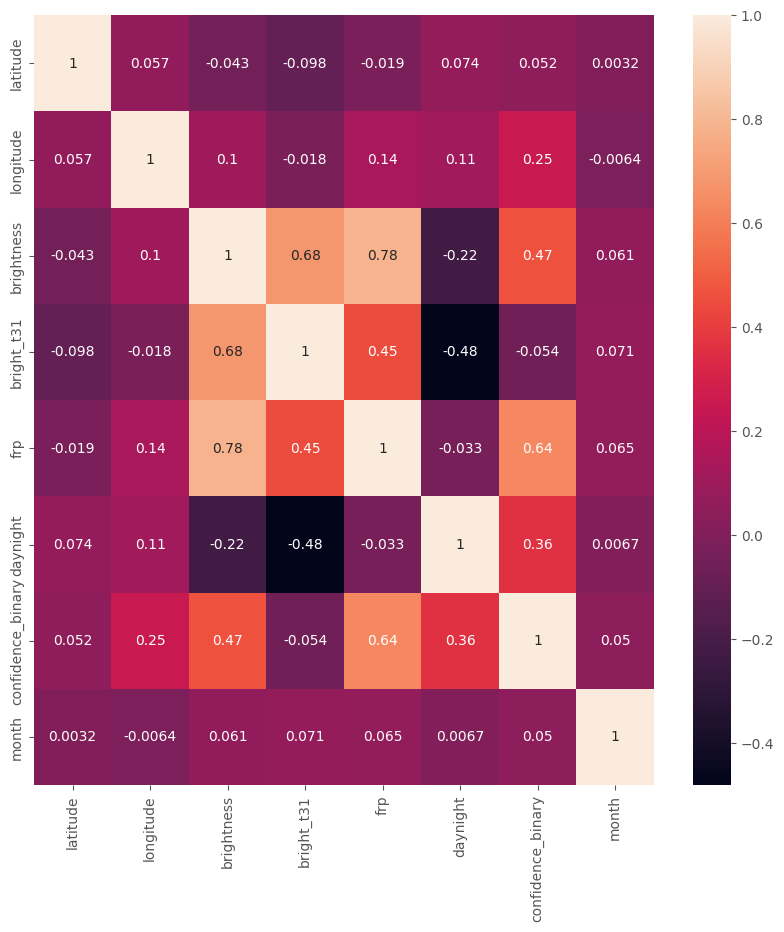

In [ ]:
# correlation between attributes, Helps detect strong relationships and remove redundant features
plt.figure(figsize=(10,10))
sns.heatmap(df_new.corr(),annot=True)

In [ ]:
df_new.shape

(14744, 8)

## Separating the target variable

In [ ]:
y= df_new['confidence_binary']


## Dropping confidence from dataset

In [ ]:
df_in= df_new.drop(['confidence_binary'],axis=1)
df_in.head()

,latitude,longitude,brightness,bright_t31,frp,daynight,month
0,24.727768,84.278347,300.00,290.00,0.00,1,1
1,23.757710,85.869250,310.84,285.83,1.88,1,1
2,23.803380,86.329920,322.66,293.69,4.59,1,1
3,23.647250,85.439650,330.14,290.23,2.64,1,1
4,23.673290,84.994910,296.59,284.16,0.82,1,1


# Splitting data in train and test

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    df_in,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
Xtrain.shape, Xtest.shape

((10320, 7), (4424, 7))

In [ ]:
Xtrain.corr()

,latitude,longitude,brightness,bright_t31,frp,daynight,month
latitude,1.000000,0.063805,-0.049808,-0.101095,-0.026409,0.063019,0.003029
longitude,0.063805,1.000000,0.103383,-0.017827,0.135018,0.113934,-0.006104
brightness,-0.049808,0.103383,1.000000,0.679781,0.774401,-0.224344,0.065050
bright_t31,-0.101095,-0.017827,0.679781,1.000000,0.439366,-0.480065,0.071024
frp,-0.026409,0.135018,0.774401,0.439366,1.000000,-0.033136,0.070767
daynight,0.063019,0.113934,-0.224344,-0.480065,-0.033136,1.000000,0.010152
month,0.003029,-0.006104,0.065050,0.071024,0.070767,0.010152,1.000000


Checking multicollinearlity and remove highly corrrelated features


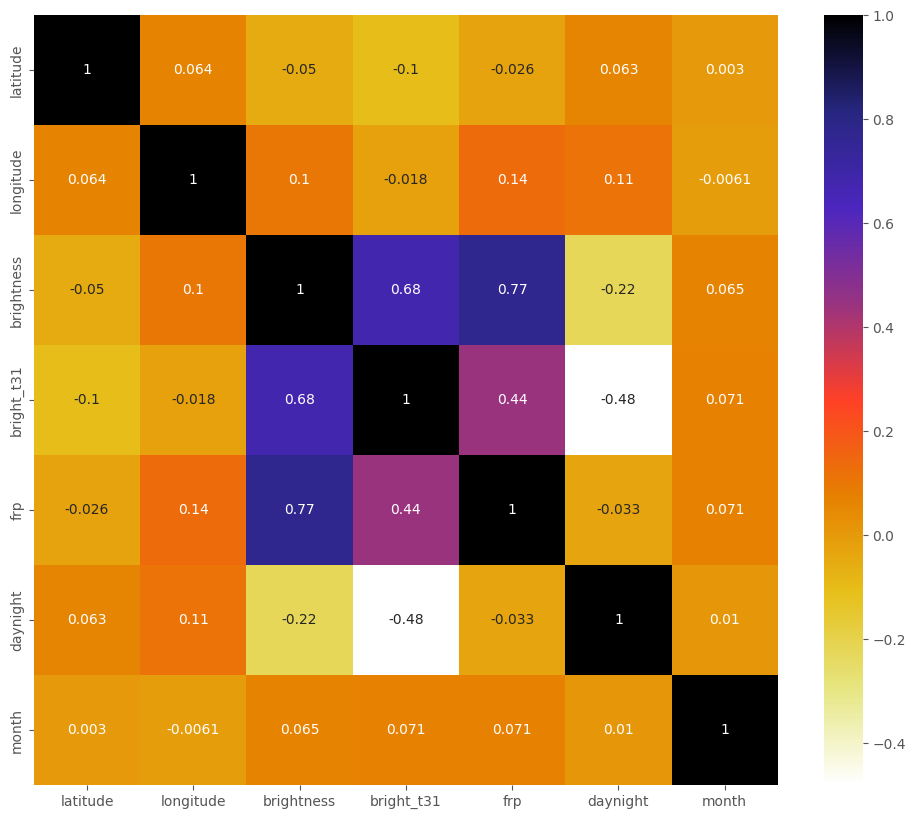

In [ ]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = Xtrain.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [ ]:
# Drop the redundant columns
Xtrain_new = Xtrain.drop(['brightness', 'bright_t31','frp'], axis=1)
Xtest_new = Xtest.drop(['brightness', 'bright_t31','frp'], axis=1)


Feature scaling Applying Standardization

In [ ]:
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain_new)
Xtest_scaled = scaler.transform(Xtest_new)


Box plot the dataset to understand effect of standard scaler

Text(0.5, 1.0, 'Xtrain After Scaling')

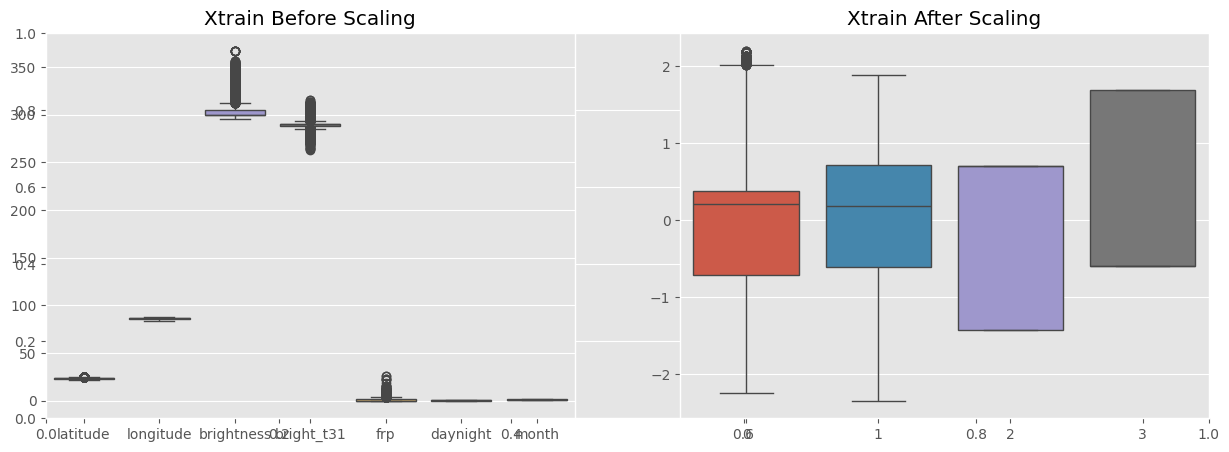

In [ ]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=Xtrain)
plt.title('Xtrain Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=Xtrain_scaled)
plt.title('Xtrain After Scaling')

##Train model

##Model Selection For Regression

Linear Regression


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


lreg = LinearRegression()
lreg.fit(Xtrain_scaled, ytrain)
lreg_pred = lreg.predict(Xtest_scaled)
mae = mean_absolute_error(ytest, lreg_pred)
r2 = r2_score(ytest, lreg_pred)

print("Linear Regression")
print ("R2 Score value: {:.4f}".format(r2))
print ("MAE value: {:.4f}".format(mae))

Linear Regression
R2 Score value: 0.1779
MAE value: 0.4109


##Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

# Decrease alpha from 1.0 to 0.01 to allow features to have impact
lasso = Lasso(alpha=0.01)
lasso.fit(Xtrain_scaled, ytrain)

lasso_pred = lasso.predict(Xtest_scaled)

# Evaluate
mae = mean_absolute_error(ytest, lasso_pred)
r2 = r2_score(ytest, lasso_pred)

print("Tuned Lasso Regression (Alpha=0.01)")
print("R2 Score value: {:.4f}".format(r2))
print("MAE value: {:.4f}".format(mae))

Tuned Lasso Regression (Alpha=0.01)
R2 Score value: 0.1773
MAE value: 0.4169


##Random forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor()
rf.fit(Xtrain_scaled, ytrain)
rf_pred = rf.predict(Xtest_scaled)
mae = mean_absolute_error(ytest, rf_pred)
r2 = r2_score(ytest, rf_pred)


print("Random Forest Regressor")
print ("R2 Score value: {:.4f}".format(r2))
print ("MAE value: {:.4f}".format(mae))

Random Forest Regressor
R2 Score value: 0.8237
MAE value: 0.0758


##K-Neighbour Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

knn = KNeighborsRegressor()
knn.fit(Xtrain_scaled, ytrain)
knn_pred = knn.predict(Xtest_scaled)
mae = mean_absolute_error(ytest, knn_pred)
r2 = r2_score(ytest, knn_pred)


print("K_Neighbours Regressor")
print ("R2 Score value: {:.4f}".format(r2))
print ("MAE value: {:.4f}".format(mae))

K_Neighbours Regressor
R2 Score value: 0.7923
MAE value: 0.0831


#Tuning Random forest Regressor

In [ ]:
param_grid = [{
    'bootstrap': [True, False],
    'max_depth': [10, 30, 50, 100, None],
    'max_features': ['sqrt', 'log2', None], # Changed 'auto' to None
    'min_samples_leaf': [1, 4],
    'min_samples_split': [2, 10],
    'n_estimators': [50, 100, 200]
}]

f_reg = RandomForestRegressor()
# n_iter=10 will pick 10 random combinations to save time
Random_rf = RandomizedSearchCV(f_reg, param_grid, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)
Random_rf.fit(Xtrain_scaled, ytrain)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions=[{'bootstrap': [True, False],
                                         'max_depth': [10, 30, 50, 100, None],
                                         'max_features': ['sqrt', 'log2', None],
                                         'min_samples_leaf': [1, 4],
                                         'min_samples_split': [2, 10],
                                         'n_estimators': [50, 100, 200]}],
                   random_state=42, verbose=2)

In [ ]:
# 1. Use the best model found by RandomizedSearchCV
best_rf = Random_rf.best_estimator_

# 2. Make predictions on the scaled test data
y_pred_tuned = best_rf.predict(Xtest_scaled)

# 3. Calculate metrics
r2_tuned = r2_score(ytest, y_pred_tuned)
mae_tuned = mean_absolute_error(ytest, y_pred_tuned)

# 4. Print results
print("--- Tuned Random Forest Regressor ---")
print("Best Parameters: ", Random_rf.best_params_)
print("R2 Score value: {:.4f}".format(r2_tuned))
print("MAE value: {:.4f}".format(mae_tuned))

--- Tuned Random Forest Regressor ---
Best Parameters:  {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
R2 Score value: 0.8277
MAE value: 0.0854


#Model Building for Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [ ]:
df_new.head()

,latitude,longitude,brightness,bright_t31,frp,daynight,confidence_binary,month
0,24.727768,84.278347,300.00,290.00,0.00,1,0,1
1,23.757710,85.869250,310.84,285.83,1.88,1,1,1
2,23.803380,86.329920,322.66,293.69,4.59,1,1,1
3,23.647250,85.439650,330.14,290.23,2.64,1,1,1
4,23.673290,84.994910,296.59,284.16,0.82,1,1,1


In [ ]:
X=df_new.drop(['confidence_binary','brightness','bright_t31','frp'],axis=1)
y=df_new['confidence_binary']

In [ ]:
X.head()

,latitude,longitude,daynight,month
0,24.727768,84.278347,1,1
1,23.757710,85.869250,1,1
2,23.803380,86.329920,1,1
3,23.647250,85.439650,1,1
4,23.673290,84.994910,1,1


In [ ]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=48)
X_train.shape, X_test.shape

((10320, 4), (4424, 4))

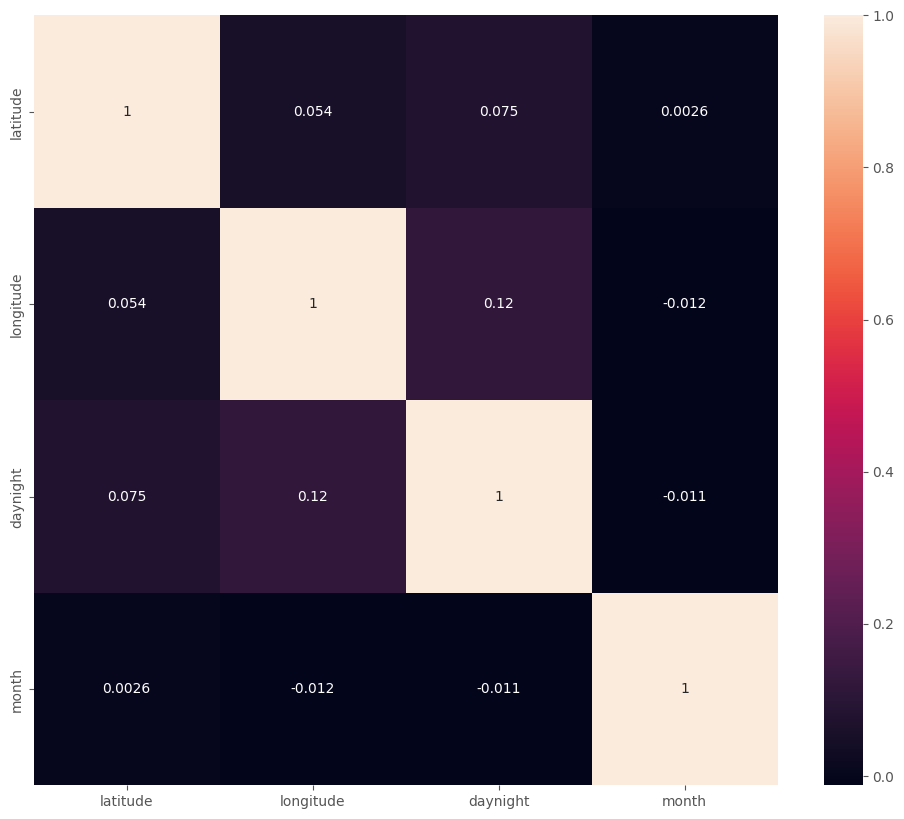

In [ ]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = X_train.corr()
sns.heatmap(cor, annot=True)
plt.show()

In [ ]:
#Features with mopre than 0.75 correlation
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
corr_features = correlation(X_train, 0.75)
corr_features

set()

In [ ]:
def scaler_standard(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

In [ ]:
X_train_scaled, X_test_scaled = scaler_standard(X_train, X_test)

#Logistic Regression

In [ ]:
# Import Logistic Regression to Train from SKlearn
loreg = LogisticRegression(max_iter=200)
loreg.fit(X_train_scaled,y_train)
loreg_pred = loreg.predict(X_test_scaled)
score = accuracy_score(y_test,loreg_pred)
cr = classification_report(y_test,loreg_pred)

print("Logistic Regression")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Logistic Regression
Accuracy Score value: 0.7419
              precision    recall  f1-score   support

           0       0.77      0.68      0.72      2171
           1       0.72      0.81      0.76      2253

    accuracy                           0.74      4424
   macro avg       0.75      0.74      0.74      4424
weighted avg       0.74      0.74      0.74      4424



##Metrics	Definition

**Precision**:	Precision is defined as the ratio of true positives to the sum of true and false positives.

**Recall**:	Recall is defined as the ratio of true positives to the sum of true positives and false negatives.

**F1 Score**:	The F1 is the weighted harmonic mean of precision and recall. The closer the value of the F1 score is to 1.0, the better the expected performance of the model is.


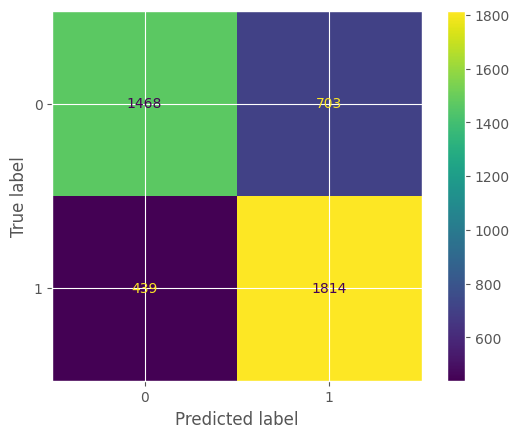

In [ ]:
loreg_cm = ConfusionMatrixDisplay.from_estimator(loreg, X_test_scaled, y_test)

## Decision tree

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_scaled,y_train)
dtc_pred = dtc.predict(X_test_scaled)
score = accuracy_score(y_test,dtc_pred)
cr = classification_report(y_test,dtc_pred)

print("Decision Tree")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Decision Tree
Accuracy Score value: 0.9369
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2171
           1       0.93      0.94      0.94      2253

    accuracy                           0.94      4424
   macro avg       0.94      0.94      0.94      4424
weighted avg       0.94      0.94      0.94      4424



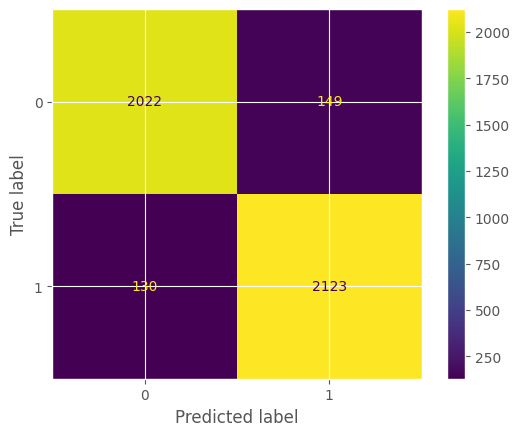

In [ ]:

dt_cm = ConfusionMatrixDisplay.from_estimator(dtc, X_test_scaled, y_test)

##Random Forest

In [ ]:

rfc = RandomForestClassifier(random_state=52)
rfc.fit(X_train_scaled,y_train)
rfc_pred = rfc.predict(X_test_scaled)
score = accuracy_score(y_test,rfc_pred)
cr = classification_report(y_test,rfc_pred)

print("Random Forest")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Random Forest
Accuracy Score value: 0.9458
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2171
           1       0.95      0.94      0.95      2253

    accuracy                           0.95      4424
   macro avg       0.95      0.95      0.95      4424
weighted avg       0.95      0.95      0.95      4424



#Random forest Classifier

In [ ]:
 # RandomForestClassifier to Train from SKlearn
knnc = RandomForestClassifier()
knnc.fit(X_train_scaled,y_train)
knn_pred = knnc.predict(X_test_scaled)
score = accuracy_score(y_test,knn_pred)
cr = classification_report(y_test,knn_pred)

print("Random forest Classifier")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

KNeighbors Classifier
Accuracy Score value: 0.9444
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      2171
           1       0.95      0.94      0.95      2253

    accuracy                           0.94      4424
   macro avg       0.94      0.94      0.94      4424
weighted avg       0.94      0.94      0.94      4424



#XG-Boost

In [ ]:

xgb = XGBClassifier()
xgb.fit(X_train_scaled,y_train)
xgb_pred = xgb.predict(X_test_scaled)
score = accuracy_score(y_test, xgb_pred)
cr = classification_report(y_test, xgb_pred)

print("XGboost Classifier")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

XGboost Classifier
Accuracy Score value: 0.9426
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2171
           1       0.95      0.94      0.94      2253

    accuracy                           0.94      4424
   macro avg       0.94      0.94      0.94      4424
weighted avg       0.94      0.94      0.94      4424



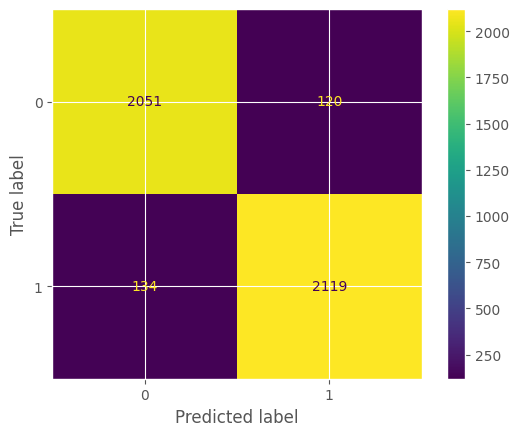

In [ ]:
xgb_cm = ConfusionMatrixDisplay.from_estimator(xgb, X_test_scaled, y_test)

#XGboost classifier Tuning

In [ ]:
params={
 "learning_rate"    : (np.linspace(0,10, 100)) ,
 "max_depth"        : (np.linspace(1,50, 25,dtype=int)),
 "min_child_weight" : [1, 3, 5, 7],
 "gamma"            : [0.0, 0.1, 0.2 , 0.3, 0.4],
 "colsample_bytree" : [0.3, 0.4, 0.5 , 0.7]}
Random_xgb = RandomizedSearchCV(xgb, params, cv = 10,n_jobs = -1)
Random_xgb.fit(X_train_scaled, y_train).best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.4, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(8.181818181818182), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(15), max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
best_xgb = Random_xgb.best_estimator_
best_xgb.score(X_test_scaled,y_test)
bestxgb_pred = best_xgb.predict(X_test_scaled)
cr = classification_report(y_test,bestxgb_pred)
print("FINAL XGB")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

FINAL XGB
Accuracy Score value: 0.9426
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      2171
           1       0.87      0.76      0.81      2253

    accuracy                           0.82      4424
   macro avg       0.82      0.82      0.82      4424
weighted avg       0.83      0.82      0.82      4424



#Random Forest classifier Tuning

In [ ]:
params = {
    "n_estimators": [90, 100, 115, 130],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 20, 1),
    'min_samples_leaf': range(1, 10, 1),
    'min_samples_split': range(2, 10, 1),
    'max_features': ['sqrt', 'log2', None]
}

# Now run the search
random_rf = RandomizedSearchCV(rfc, params, cv=10, n_jobs=-1, n_iter=10, random_state=42)
best_model = random_rf.fit(X_train_scaled, y_train).best_estimator_

print("Best Model Found:")
print(best_model)


Best Model Found:
RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=7,
                       n_estimators=90, random_state=52)


In [ ]:
best_rf = random_rf.best_estimator_
best_rf.score(X_test_scaled,y_test)
bestrf_pred = best_rf.predict(X_test_scaled)
cr = classification_report(y_test,bestrf_pred)
print("FINAL Random Forest")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

FINAL Random Forest
Accuracy Score value: 0.9426
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2171
           1       0.95      0.93      0.94      2253

    accuracy                           0.94      4424
   macro avg       0.94      0.94      0.94      4424
weighted avg       0.94      0.94      0.94      4424



##Random forest classifier Confusion Matrix

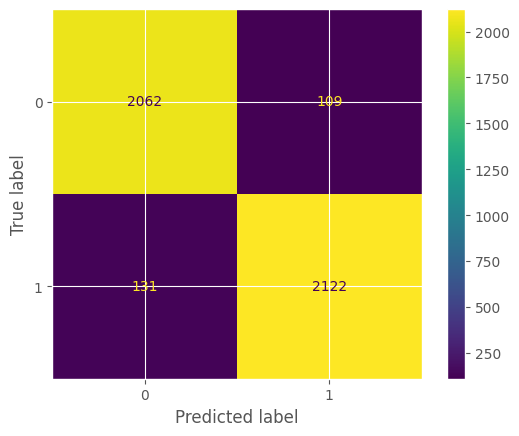

In [ ]:
rf_cm = ConfusionMatrixDisplay.from_estimator(rfc, X_test_scaled, y_test)

#Model Selection

Applying Stratified Kfold Cross-Validation to know the exact Mean CV Accuracy Score for all models

Implementing the concept of StratifiedK fold sampling in cross-validation ensures the training and test sets have the same proportion of the feature of interest as in the original dataset. Doing this with the target variable ensures good accuracy without error.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skfold = StratifiedKFold(n_splits= 10,shuffle= True,random_state= 36)

In [ ]:
cv_xgb= cross_val_score(best_xgb,X,y,cv=skfold,scoring='accuracy').mean()
print('CV Score XGB Tuned {:.4f}'.format(cv_xgb))

CV Score XGB Tuned 0.7391


In [ ]:
cv_rf=cross_val_score(rfc,X,y,cv=skfold,scoring="accuracy").mean()
print('CV Score Random Forest {:.4f}'.format(cv_rf))

CV Score Random Forest 0.9489


In [ ]:
import joblib

# Save your final model
joblib.dump(best_rf, 'jharkhand_fire_model.pkl')



print("Success! You generated 'jharkhand_fire_model.pkl'.")


Success! You generated 'jharkhand_fire_model.pkl'.


From the above result Random forest Classifier has given better Result so will proceed with that model for model Deployment